### Objective

### Problem Statement 

### Data Overview

## 1: Load the automobile dataset using Pandas

In [5]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

In [6]:
adf  = pd.DataFrame(pd.read_csv("Automobile_data.csv"))
adf

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,?,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,23,28,16845
201,-1,95,volvo,gas,sedan,rwd,front,68.8,55.5,ohc,141,160,19,25,19045
202,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohcv,173,134,18,23,21485
203,-1,95,volvo,diesel,sedan,rwd,front,68.9,55.5,ohc,145,106,26,27,22470


### Check number of rows, columns, size

In [315]:
adf.axes

[RangeIndex(start=0, stop=205, step=1),
 Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'body-style',
        'drive-wheels', 'engine-location', 'width', 'height', 'engine-type',
        'engine-size', 'horsepower', 'city-mpg', 'highway-mpg', 'price'],
       dtype='object')]

### Column names and datatypes

In [316]:
adf.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'body-style',
       'drive-wheels', 'engine-location', 'width', 'height', 'engine-type',
       'engine-size', 'horsepower', 'city-mpg', 'highway-mpg', 'price'],
      dtype='object')

### Dataset info and statistics

In [317]:
adf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    int64  
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    int64  
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(2), int64(7), object(6)
memory usage: 24.2+ KB


In [318]:
adf.describe()

,symboling,normalized-losses,width,height,engine-size,horsepower,city-mpg,highway-mpg,price
count,205.000000,205.00000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,118.20000,65.907805,53.724878,126.907317,104.165854,25.219512,30.751220,13227.478049
std,1.245307,32.58419,2.145204,2.443522,41.642693,39.529733,6.542142,6.886443,7902.651615
min,-2.000000,65.00000,60.300000,47.800000,61.000000,48.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.00000,64.100000,52.000000,97.000000,70.000000,19.000000,25.000000,7788.000000
50%,1.000000,103.00000,65.500000,54.100000,120.000000,95.000000,24.000000,30.000000,10345.000000
75%,2.000000,137.00000,66.900000,55.500000,141.000000,116.000000,30.000000,34.000000,16500.000000
max,3.000000,256.00000,72.300000,59.800000,326.000000,288.000000,49.000000,54.000000,45400.000000


### First 10 and Last 5 rows

In [319]:
adf.head(10)

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,103,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,103,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,103,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450
5,2,103,audi,gas,sedan,fwd,front,66.3,53.1,ohc,136,110,19,25,15250
6,1,158,audi,gas,sedan,fwd,front,71.4,55.7,ohc,136,110,19,25,17710
7,1,103,audi,gas,wagon,fwd,front,71.4,55.7,ohc,136,110,19,25,18920
8,1,158,audi,gas,sedan,fwd,front,71.4,55.9,ohc,131,140,17,20,23875
9,0,103,audi,gas,hatchback,4wd,front,67.9,52.0,ohc,131,160,16,22,12000


In [320]:
adf.tail()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
200,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,23,28,16845
201,-1,95,volvo,gas,sedan,rwd,front,68.8,55.5,ohc,141,160,19,25,19045
202,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohcv,173,134,18,23,21485
203,-1,95,volvo,diesel,sedan,rwd,front,68.9,55.5,ohc,145,106,26,27,22470
204,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,19,25,22625


## 2: Data Preprocessing – Identify Data Quality Issues

In [321]:
def DataPreprovessing(col):
   
    print("="*145)
    print()
    print(f"Unique values of {col}: {adf[col].unique()}", end = " ")
    print()
    print(f"Number of Unique values of {col}: {adf[col].nunique()}",end = " ")
    print()
    print("="*145)

#### Categorical Columns

In [322]:
category = adf.drop(["symboling","width", "height", "engine-size", "city-mpg", "highway-mpg","price","horsepower","normalized-losses"],axis = 1)
for col in category:
    DataPreprovessing(col)


Unique values of make: ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo'] 
Number of Unique values of make: 22 

Unique values of fuel-type: ['gas' 'diesel'] 
Number of Unique values of fuel-type: 2 

Unique values of body-style: ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop'] 
Number of Unique values of body-style: 5 

Unique values of drive-wheels: ['rwd' 'fwd' '4wd'] 
Number of Unique values of drive-wheels: 3 

Unique values of engine-location: ['front' 'rear'] 
Number of Unique values of engine-location: 2 

Unique values of engine-type: ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv'] 
Number of Unique values of engine-type: 7 


#### Numerical Columns

In [323]:
for col in ["symboling","width", "height", "engine-size", "city-mpg", "highway-mpg","price","horsepower","normalized-losses"]:
    DataPreprovessing(col)


Unique values of symboling: [ 3  1  2  0 -1 -2] 
Number of Unique values of symboling: 6 

Unique values of width: [64.1 65.5 66.2 66.4 66.3 71.4 67.9 64.8 66.9 70.9 60.3 63.6 63.8 64.6
 63.9 64.  65.2 62.5 66.  61.8 69.6 70.6 64.2 65.7 66.5 66.1 70.3 71.7
 70.5 72.  68.  64.4 65.4 68.4 68.3 65.  72.3 66.6 63.4 65.6 67.7 67.2
 68.9 68.8] 
Number of Unique values of width: 44 

Unique values of height: [48.8 52.4 54.3 53.1 55.7 55.9 52.  53.7 56.3 53.2 50.8 50.6 59.8 50.2
 52.6 54.5 58.3 53.3 54.1 51.  53.5 51.4 52.8 47.8 49.6 55.5 54.4 56.5
 58.7 54.9 56.7 55.4 54.8 49.4 51.6 54.7 55.1 56.1 49.7 56.  50.5 55.2
 52.5 53.  59.1 53.9 55.6 56.2 57.5] 
Number of Unique values of height: 49 

Unique values of engine-size: [130 152 109 136 131 108 164 209  61  90  98 122 156  92  79 110 111 119
 258 326  91  70  80 140 134 183 234 308 304  97 103 120 181 151 194 203
 132 121 146 171 161 141 173 145] 
Number of Unique values of engine-size: 44 

Unique values of city-mpg: [21 19 24 18 17 16 2

##  3: Handle Missing Values

In [324]:
adf.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
body-style           0
drive-wheels         0
engine-location      0
width                0
height               0
engine-type          0
engine-size          0
horsepower           0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

##  4: Data Type Correction

In [325]:
adf.dtypes 

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
body-style            object
drive-wheels          object
engine-location       object
width                float64
height               float64
engine-type           object
engine-size            int64
horsepower             int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

#### normalized-losses

In [326]:
adf["normalized-losses"] = adf["normalized-losses"].replace("?", np.nan)
pd.to_numeric(adf["normalized-losses"], errors= 'coerce')

0      103
1      103
2      103
3      164
4      164
      ... 
200     95
201     95
202     95
203     95
204     95
Name: normalized-losses, Length: 205, dtype: int64

In [327]:
adf["normalized-losses"] = adf["normalized-losses"].fillna(103)

In [328]:
adf['normalized-losses'] = adf['normalized-losses'].astype(int)

#### horsepower

In [329]:
adf["horsepower"] = pd.to_numeric(adf["horsepower"].replace("?",np.nan ), errors = 'coerce')

In [330]:
adf['horsepower'] = adf['horsepower'].fillna(adf['horsepower'].median())
adf['horsepower'] = adf['horsepower'].astype(int)

#### engine-size

In [331]:
adf["engine-size"].astype(int)

0      130
1      130
2      152
3      109
4      136
      ... 
200    141
201    141
202    173
203    145
204    141
Name: engine-size, Length: 205, dtype: int64

In [332]:
adf.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
body-style            object
drive-wheels          object
engine-location       object
width                float64
height               float64
engine-type           object
engine-size            int64
horsepower             int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

##  5: Handle Duplicate Records

In [333]:
adf.duplicated().sum()

np.int64(0)

## 6: Outlier Detection & Treatment

In [1]:
def OutliersDetectionTreatment(col):
    print(f"Outlier Detection for {col}")
    q1 = np.percentile(adf[col],25)
    q3 = np.percentile(adf[col],75)

    IQR = q3-q1

    LT = q1 - IQR * 1.5
    UT = q3 + IQR * 1.5

    Outlier = adf[(adf[col] < LT) | (adf[col] > UT) ]
    print("Outliers are handled by using Copping method for column",col)
    adf[col] = adf[col].clip(LT,UT)

    ax = sns.boxplot(adf[col], color = 'orange')
    ax.set_title("Visual Representation Of Above Column Values After Outlier Handling", fontsize = 10, weight = 'bold', color = 'black') 
    plt.show()
    print("="*100)

Outlier Detection for symboling
Outliers are handled by using Copping method for column symboling


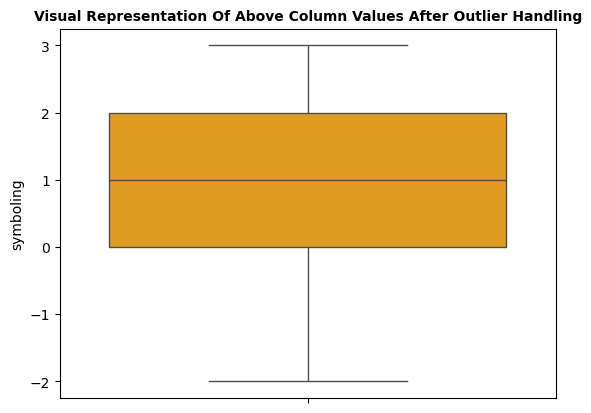

Outlier Detection for width
Outliers are handled by using Copping method for column width


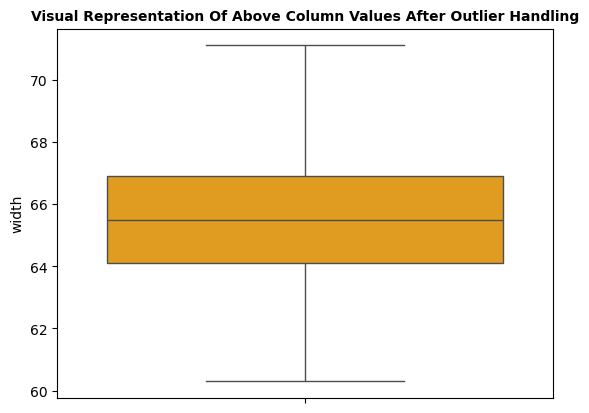

Outlier Detection for height
Outliers are handled by using Copping method for column height


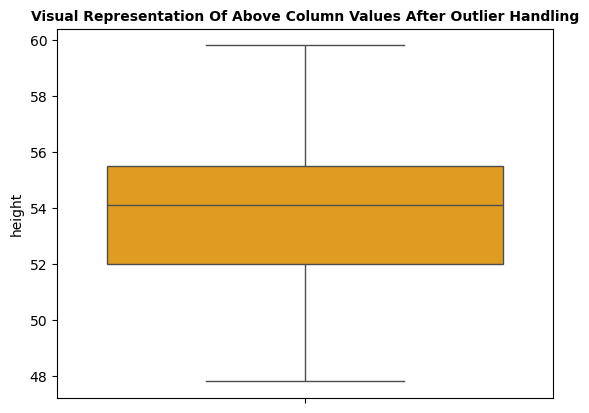

Outlier Detection for engine-size
Outliers are handled by using Copping method for column engine-size


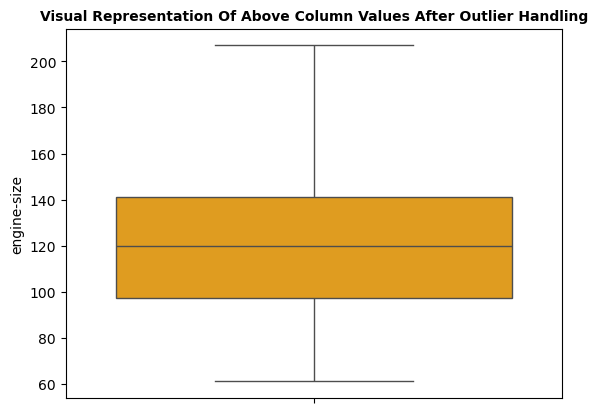

Outlier Detection for city-mpg
Outliers are handled by using Copping method for column city-mpg


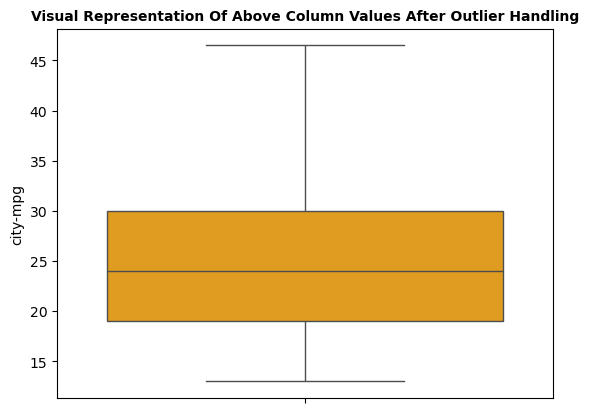

Outlier Detection for highway-mpg
Outliers are handled by using Copping method for column highway-mpg


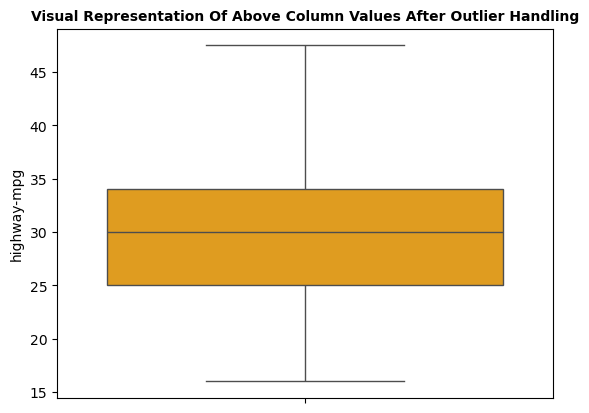

Outlier Detection for price
Outliers are handled by using Copping method for column price


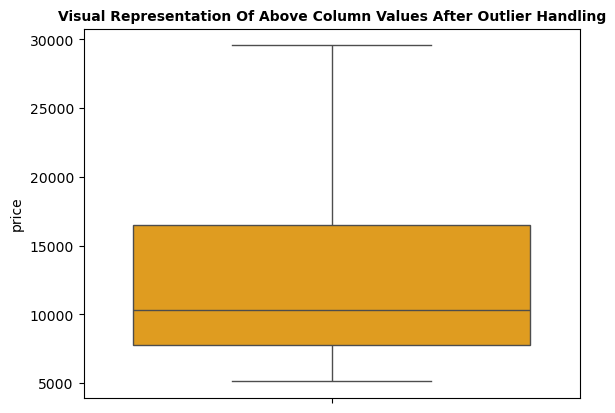

Outlier Detection for horsepower
Outliers are handled by using Copping method for column horsepower


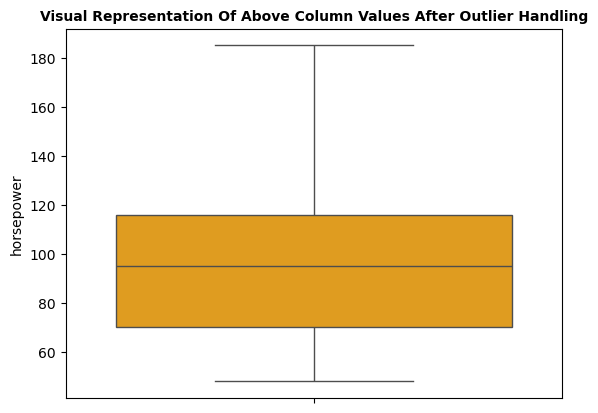

Outlier Detection for normalized-losses
Outliers are handled by using Copping method for column normalized-losses


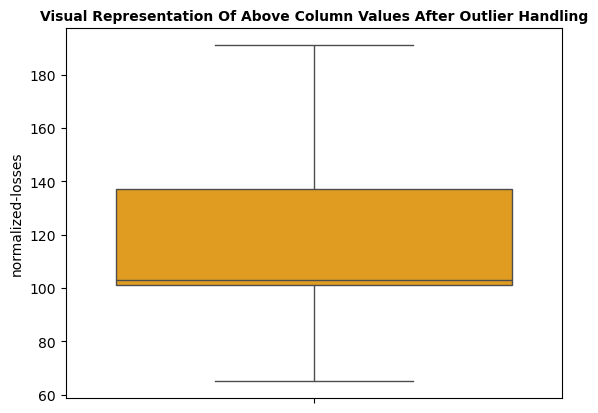

In [335]:
for col in ["symboling","width", "height", "engine-size", "city-mpg", "highway-mpg","price","horsepower","normalized-losses"]:
    OutliersDetectionTreatment(col)

## 7: Feature Scaling

In [341]:
sc = StandardScaler()
for i in ["symboling","width", "height", "engine-size", "city-mpg", "highway-mpg","price","horsepower","normalized-losses"]:
    adf[i] = sc.fit_transform(adf[[i]])

In [342]:
adf.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,1.743470,-0.476253,alfa-romero,gas,convertible,rwd,front,-0.858695,-2.020417,dohc,0.160196,0.228518,-0.649321,-0.552143,0.106474
1,1.743470,-0.476253,alfa-romero,gas,convertible,rwd,front,-0.858695,-2.020417,dohc,0.160196,0.228518,-0.649321,-0.552143,0.560611
2,0.133509,-0.476253,alfa-romero,gas,hatchback,rwd,front,-0.184978,-0.543527,ohcv,0.809329,1.440545,-0.958163,-0.702161,0.560611
3,0.938490,1.514901,audi,gas,sedan,fwd,front,0.151880,0.235942,ohc,-0.459430,-0.025162,-0.186058,-0.102086,0.175237
4,0.938490,1.514901,audi,gas,sedan,4wd,front,0.248125,0.235942,ohc,0.337232,0.341265,-1.112584,-1.302237,0.704181


##  8: Categorical Encoding

In [343]:
le = LabelEncoder()

In [344]:
category = adf.drop(["symboling","width", "height", "engine-size", "city-mpg", "highway-mpg","price","horsepower","normalized-losses"],axis = 1)
for col in category:
    adf[col] = le.fit_transform(adf[col]) 

In [345]:
adf.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,1.743470,-0.476253,0,1,0,2,0,-0.858695,-2.020417,0,0.160196,0.228518,-0.649321,-0.552143,0.106474
1,1.743470,-0.476253,0,1,0,2,0,-0.858695,-2.020417,0,0.160196,0.228518,-0.649321,-0.552143,0.560611
2,0.133509,-0.476253,0,1,2,2,0,-0.184978,-0.543527,5,0.809329,1.440545,-0.958163,-0.702161,0.560611
3,0.938490,1.514901,1,1,3,1,0,0.151880,0.235942,3,-0.459430,-0.025162,-0.186058,-0.102086,0.175237
4,0.938490,1.514901,1,1,3,0,0,0.248125,0.235942,3,0.337232,0.341265,-1.112584,-1.302237,0.704181


##  9: Feature Engineering

In [346]:
adf["price/horsepower"] = adf["price"]/adf["horsepower"]
adf.head()


,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price,price/horsepower
0,1.743470,-0.476253,0,1,0,2,0,-0.858695,-2.020417,0,0.160196,0.228518,-0.649321,-0.552143,0.106474,0.465931
1,1.743470,-0.476253,0,1,0,2,0,-0.858695,-2.020417,0,0.160196,0.228518,-0.649321,-0.552143,0.560611,2.453241
2,0.133509,-0.476253,0,1,2,2,0,-0.184978,-0.543527,5,0.809329,1.440545,-0.958163,-0.702161,0.560611,0.389166
3,0.938490,1.514901,1,1,3,1,0,0.151880,0.235942,3,-0.459430,-0.025162,-0.186058,-0.102086,0.175237,-6.964400
4,0.938490,1.514901,1,1,3,0,0,0.248125,0.235942,3,0.337232,0.341265,-1.112584,-1.302237,0.704181,2.063444


# Visualization 

### Price vs. Horsepower

Text(0.0, 1.0, 'Price based on Horsepower')

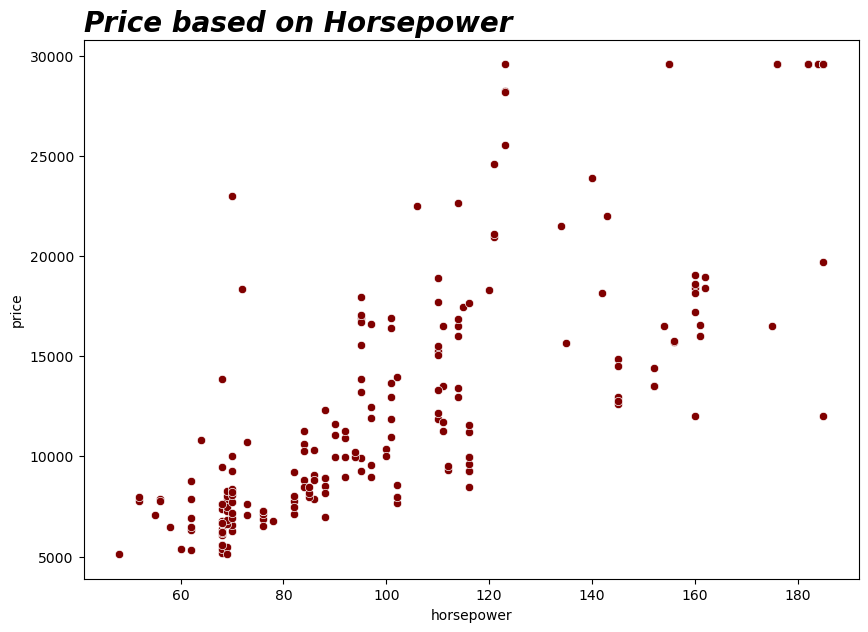

In [336]:
plt.figure(figsize = (10,7))
sns.scatterplot(x = adf["horsepower"], y = adf["price"],color = 'maroon')
plt.title("Price based on Horsepower", fontsize = 20, fontstyle = 'oblique', weight = 'bold',loc = 'left')

## Price based on Engine Size and Fuel-type

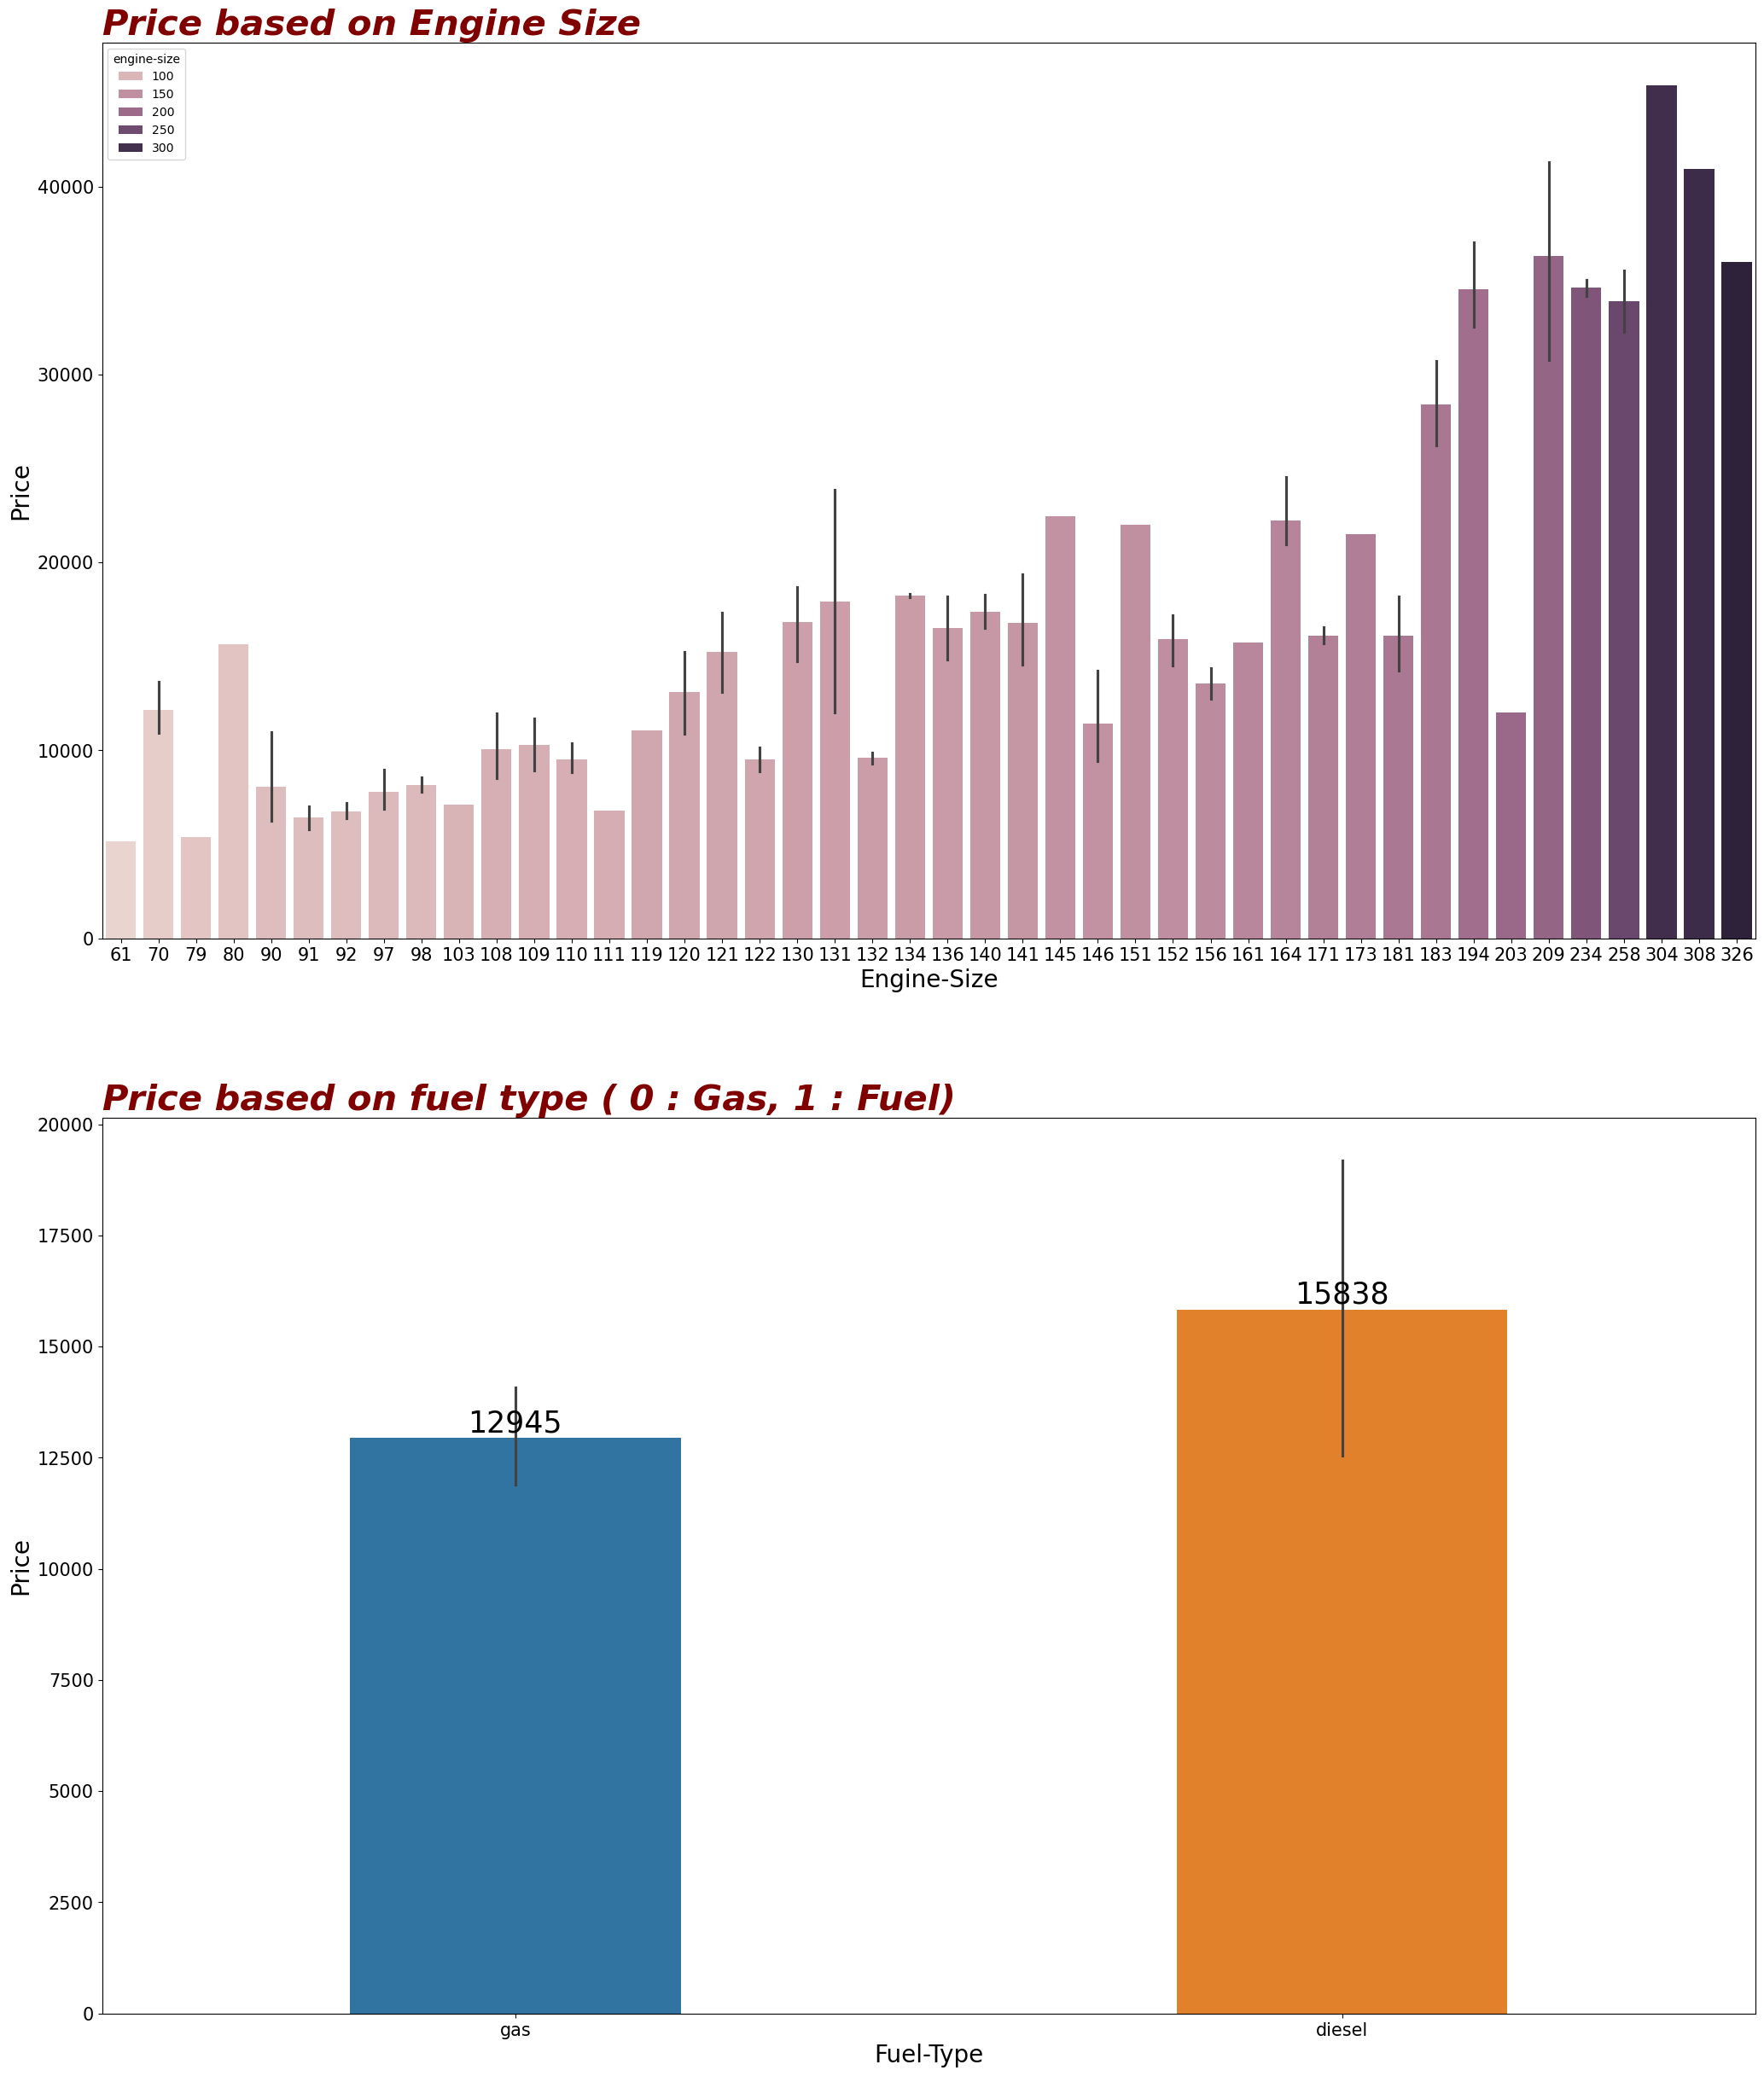

In [7]:
fig,ax = plt.subplots(2,1,figsize = (25,30))
sns.barplot(x = adf['engine-size'], y = adf['price'],hue = adf['engine-size'], units= True,ax = ax[0])
ax[0].set_title("Price based on Engine Size", loc = "left",fontsize = 30, color = 'maroon',fontweight="bold",fontstyle = 'italic')
ax[0].set_xlabel("Engine-Size", fontsize = 20)
ax[0].set_ylabel("Price", fontsize = 20)
ax[0].tick_params(axis = 'x', labelsize = 15)
ax[0].tick_params(axis = 'y', labelsize = 15)


sns.barplot(x = adf['fuel-type'], y =  adf['price'],hue = adf['fuel-type'],width = .4,ax = ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, fmt = "%.0f", fontsize = 25,color = 'black')

ax[1].set_title("Price based on fuel type ( 0 : Gas, 1 : Fuel)", loc = "left",fontsize = 30, color = 'maroon',fontweight="bold",fontstyle = 'italic')
ax[1].set_xlabel("Fuel-Type", fontsize = 20)
ax[1].set_ylabel("Price", fontsize = 20)
ax[1].tick_params(axis = 'x', labelsize = 15)
ax[1].tick_params(axis = 'y', labelsize = 15)

### Compare average price of each brand & price distribution for body styles





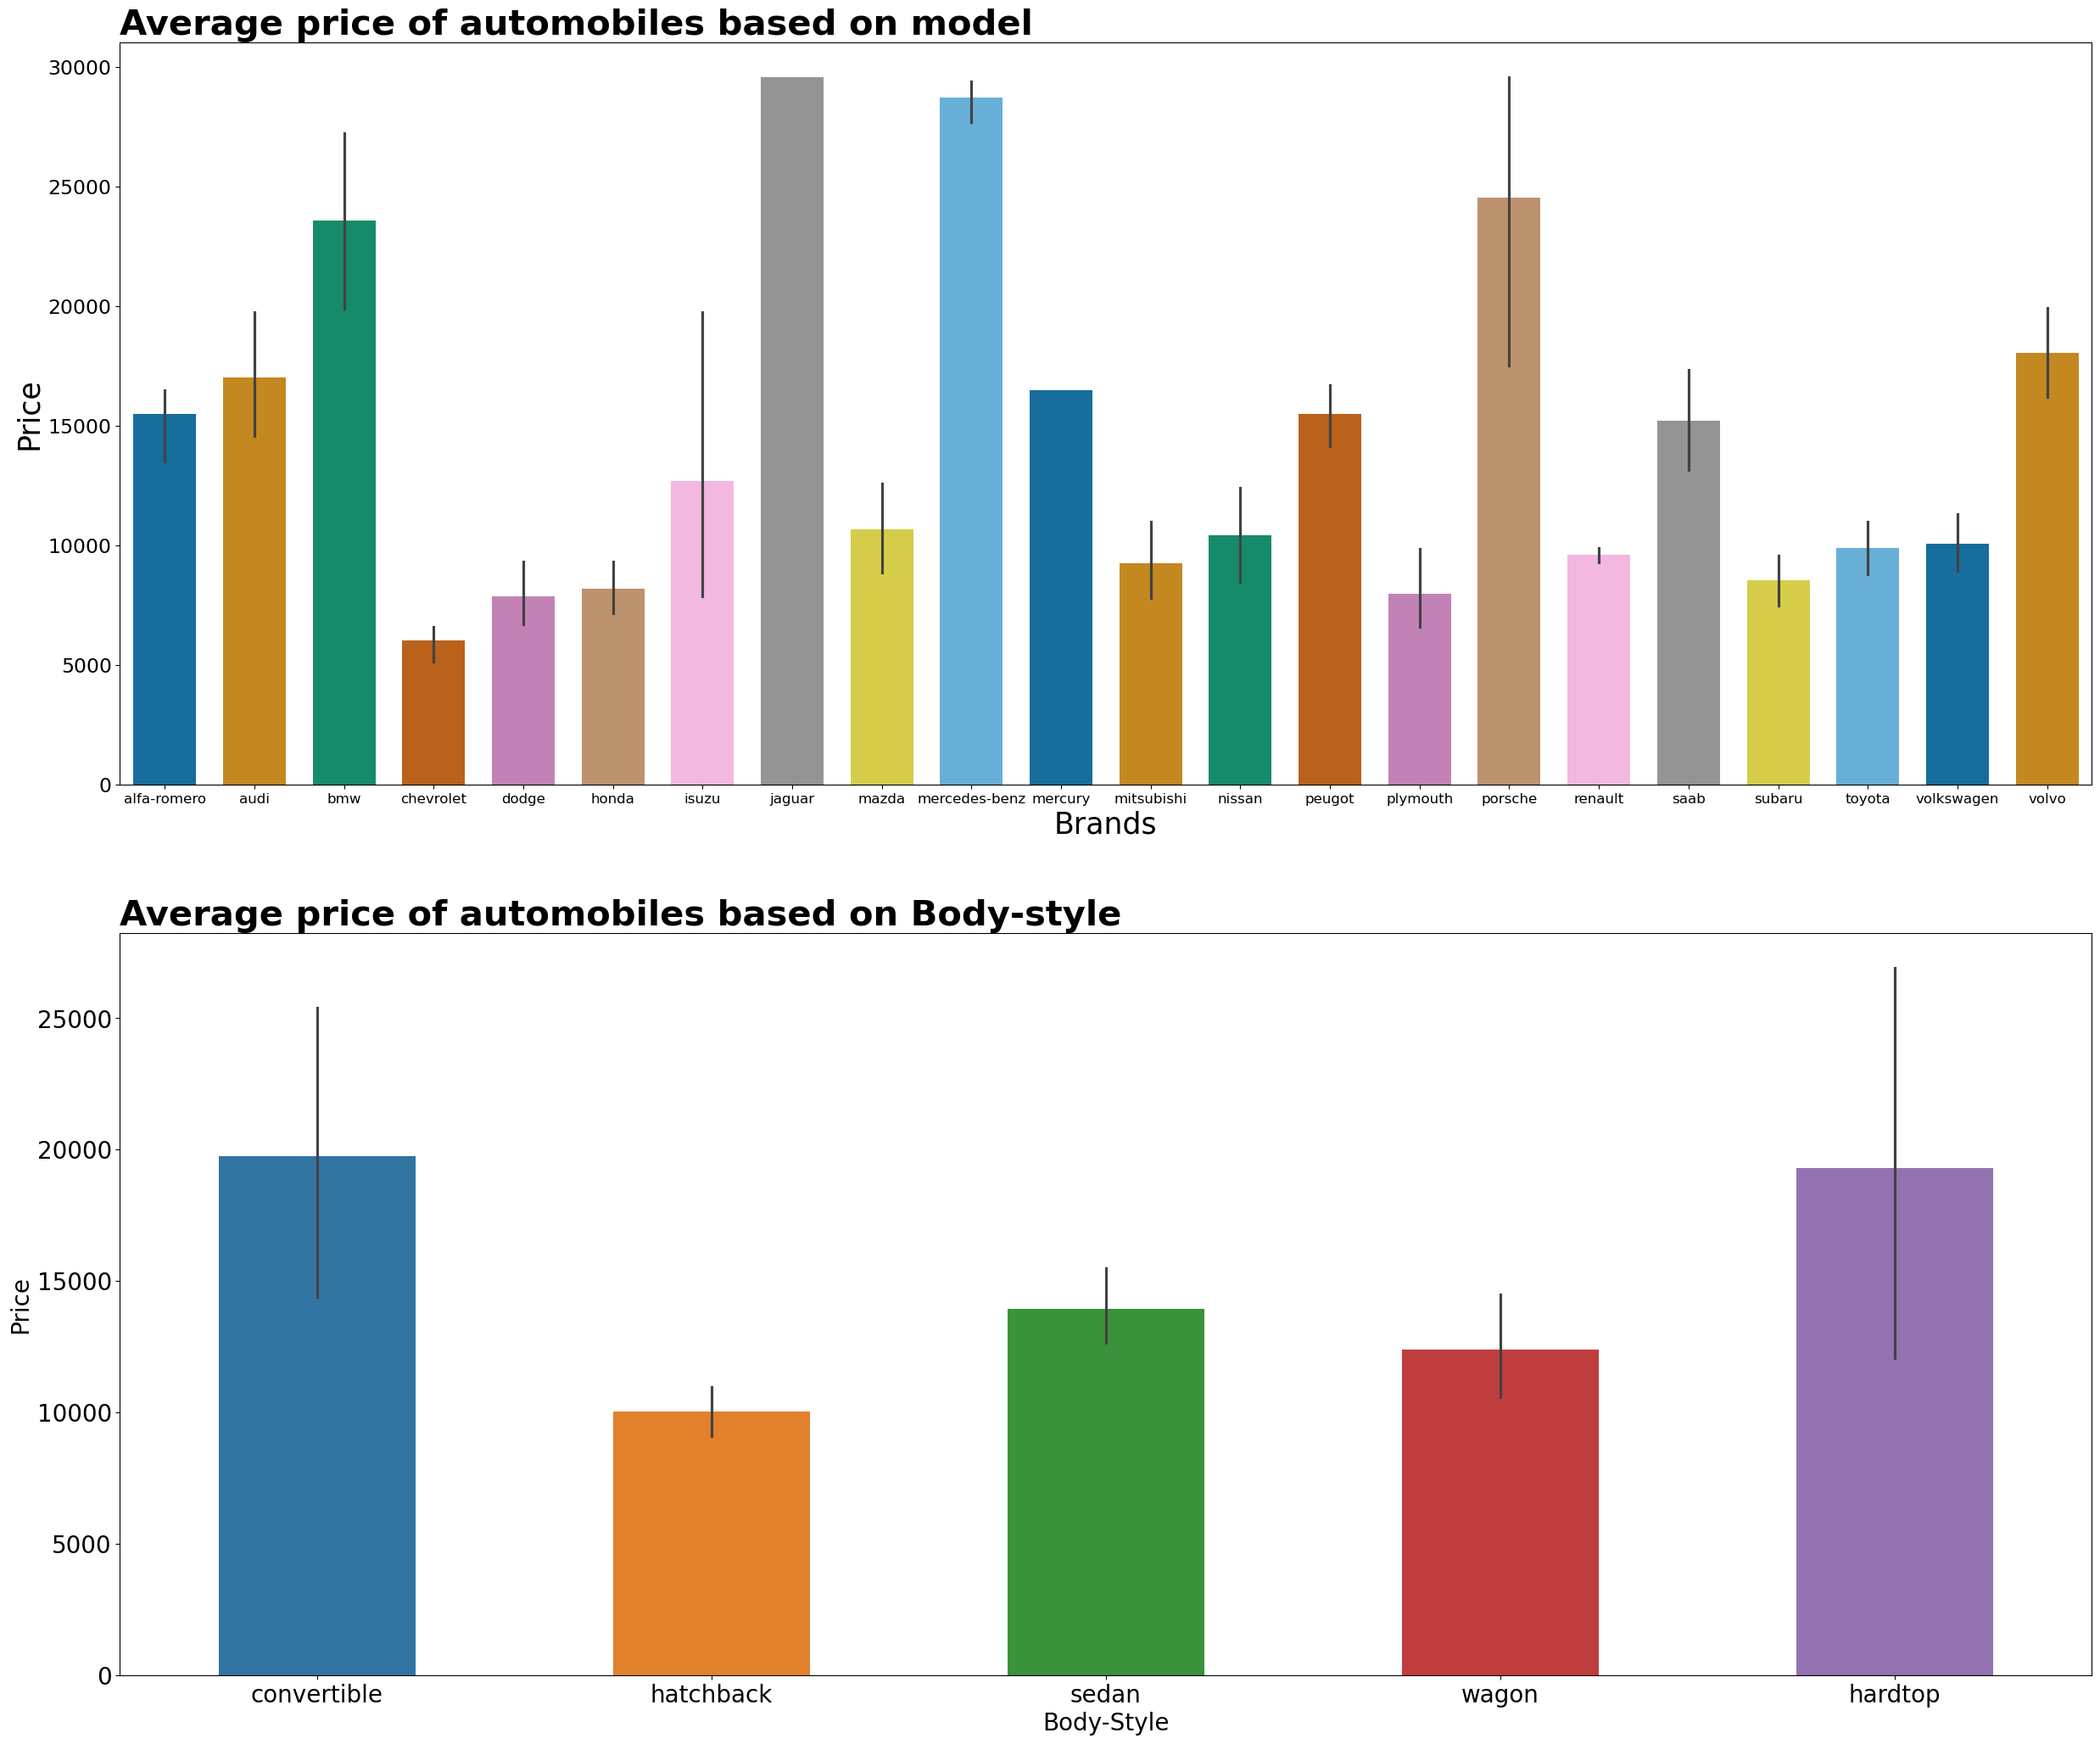

In [338]:
fig,ax = plt.subplots(2,1,figsize = (30,25))

# Chart1

sns.barplot(x =  adf['make'], y = adf['price'],hue =  adf['make'],palette = 'colorblind',ax =ax[0],width = .7)

ax[0].set_title("Average price of automobiles based on model",loc = 'left', fontsize = 30, weight = 'bold')
ax[0].set_xlabel("Brands", fontsize = 25)
ax[0].set_ylabel("Price", fontsize = 25)
ax[0].tick_params(axis = 'x', labelsize = 12,width = .8) 
ax[0].tick_params(axis = 'y', labelsize = 17) 

# Chart 2

sns.barplot(x = adf['body-style'], y = adf['price'], hue = adf['body-style'], ax = ax[1],width = .5)

ax[1].set_title("Average price of automobiles based on Body-style",loc = 'left', fontsize = 30, weight = 'bold')
ax[1].set_xlabel("Body-Style", fontsize = 20)
ax[1].set_ylabel("Price", fontsize = 20)
ax[1].tick_params(axis = 'x', labelsize = 20) 
ax[1].tick_params(axis = 'y', labelsize = 20) 

plt.show()

### Analyze price based on horsepower & price based on vehicle weight

Text(0.5, 0, 'Vehicle Weight')

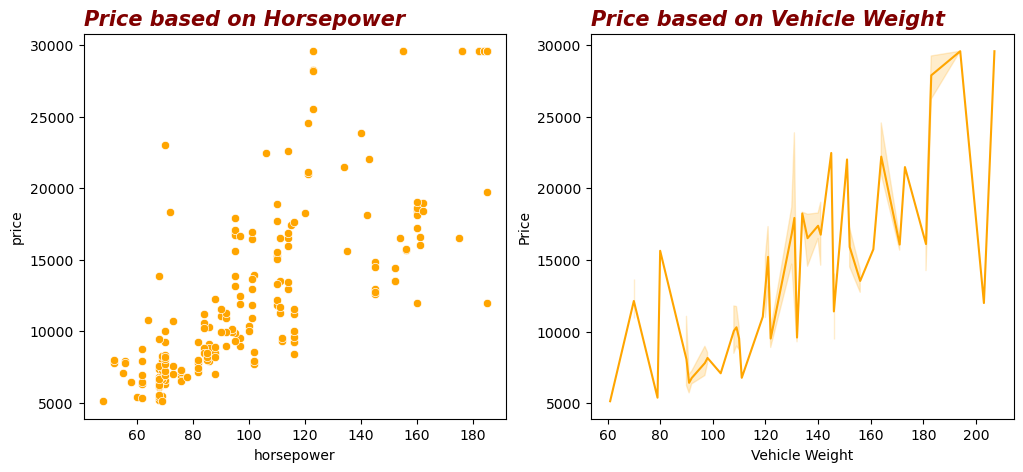

In [339]:
fig, ax = plt.subplots(1,2, figsize = (12,5))

#Chart 1
sns.scatterplot(x = adf['horsepower'], y = adf["price"], ax = ax[0], color = 'orange')
ax[0].set_title("Price based on Horsepower", fontsize = 15, loc = 'left', fontstyle = 'oblique', weight = 'bold',color = 'maroon')


#Chart 2
sns.lineplot(x = adf['engine-size'], y = adf['price'], color = 'orange', ax = ax[1] )
ax[1].set_title("Price based on Vehicle Weight", color = 'maroon', fontsize = 15,loc = 'left', fontstyle = 'oblique', weight = 'bold')
ax[1].set_ylabel("Price", fontsize = 10, color = 'black')
ax[1].set_xlabel("Vehicle Weight", fontsize = 10, color = 'black')

### Compare engine size with fuel efficiency & price by drive type





Text(0.0, 1.0, 'Price based on Drive type')

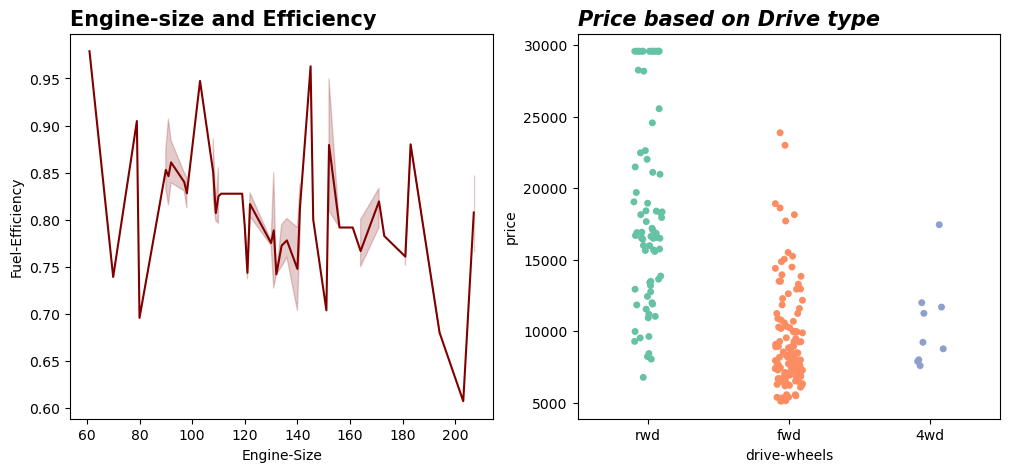

In [340]:
fig,ax = plt.subplots(1,2, figsize = (12,5))
sns.lineplot(x = adf["engine-size"], y =  (adf["city-mpg"]/adf["highway-mpg"]), color = 'maroon', ax = ax[0])
ax[0].set_ylabel('Fuel-Efficiency')
ax[0].set_xlabel('Engine-Size')
ax[0].set_title("Engine-size and Efficiency", fontsize = 15, color = 'black',loc = 'left', weight = 'bold')

sns.stripplot(x = adf['drive-wheels'], y = adf['price'], hue = adf['drive-wheels'],palette = 'Set2', ax = ax[1])
ax[1].set_title("Price based on Drive type", fontsize = 15, fontstyle = 'oblique', color = 'black',loc = 'left', weight= 'bold')

### View multiple relationships together




<Axes: >

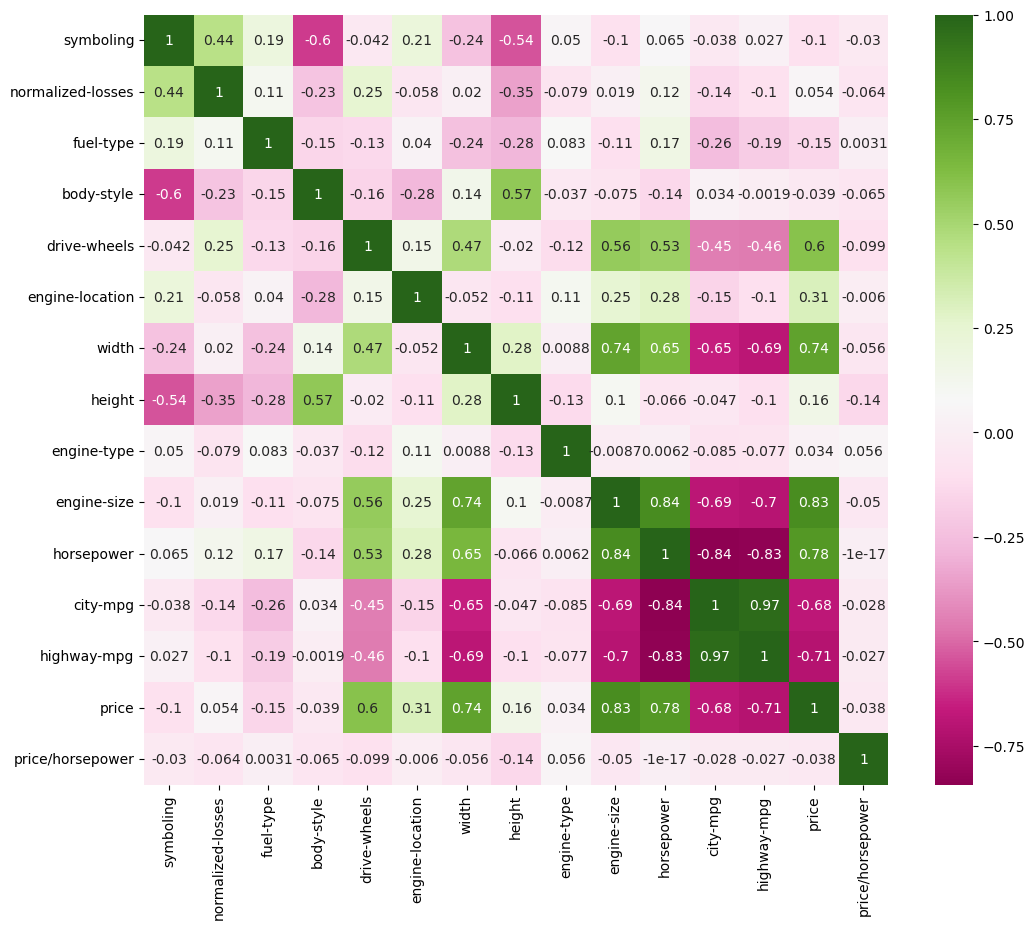

In [347]:
clean = adf.drop('make',axis = 1)
plt.figure(figsize = (12,10))
sns.heatmap(clean.corr(), annot = True, cmap = 'PiYG')

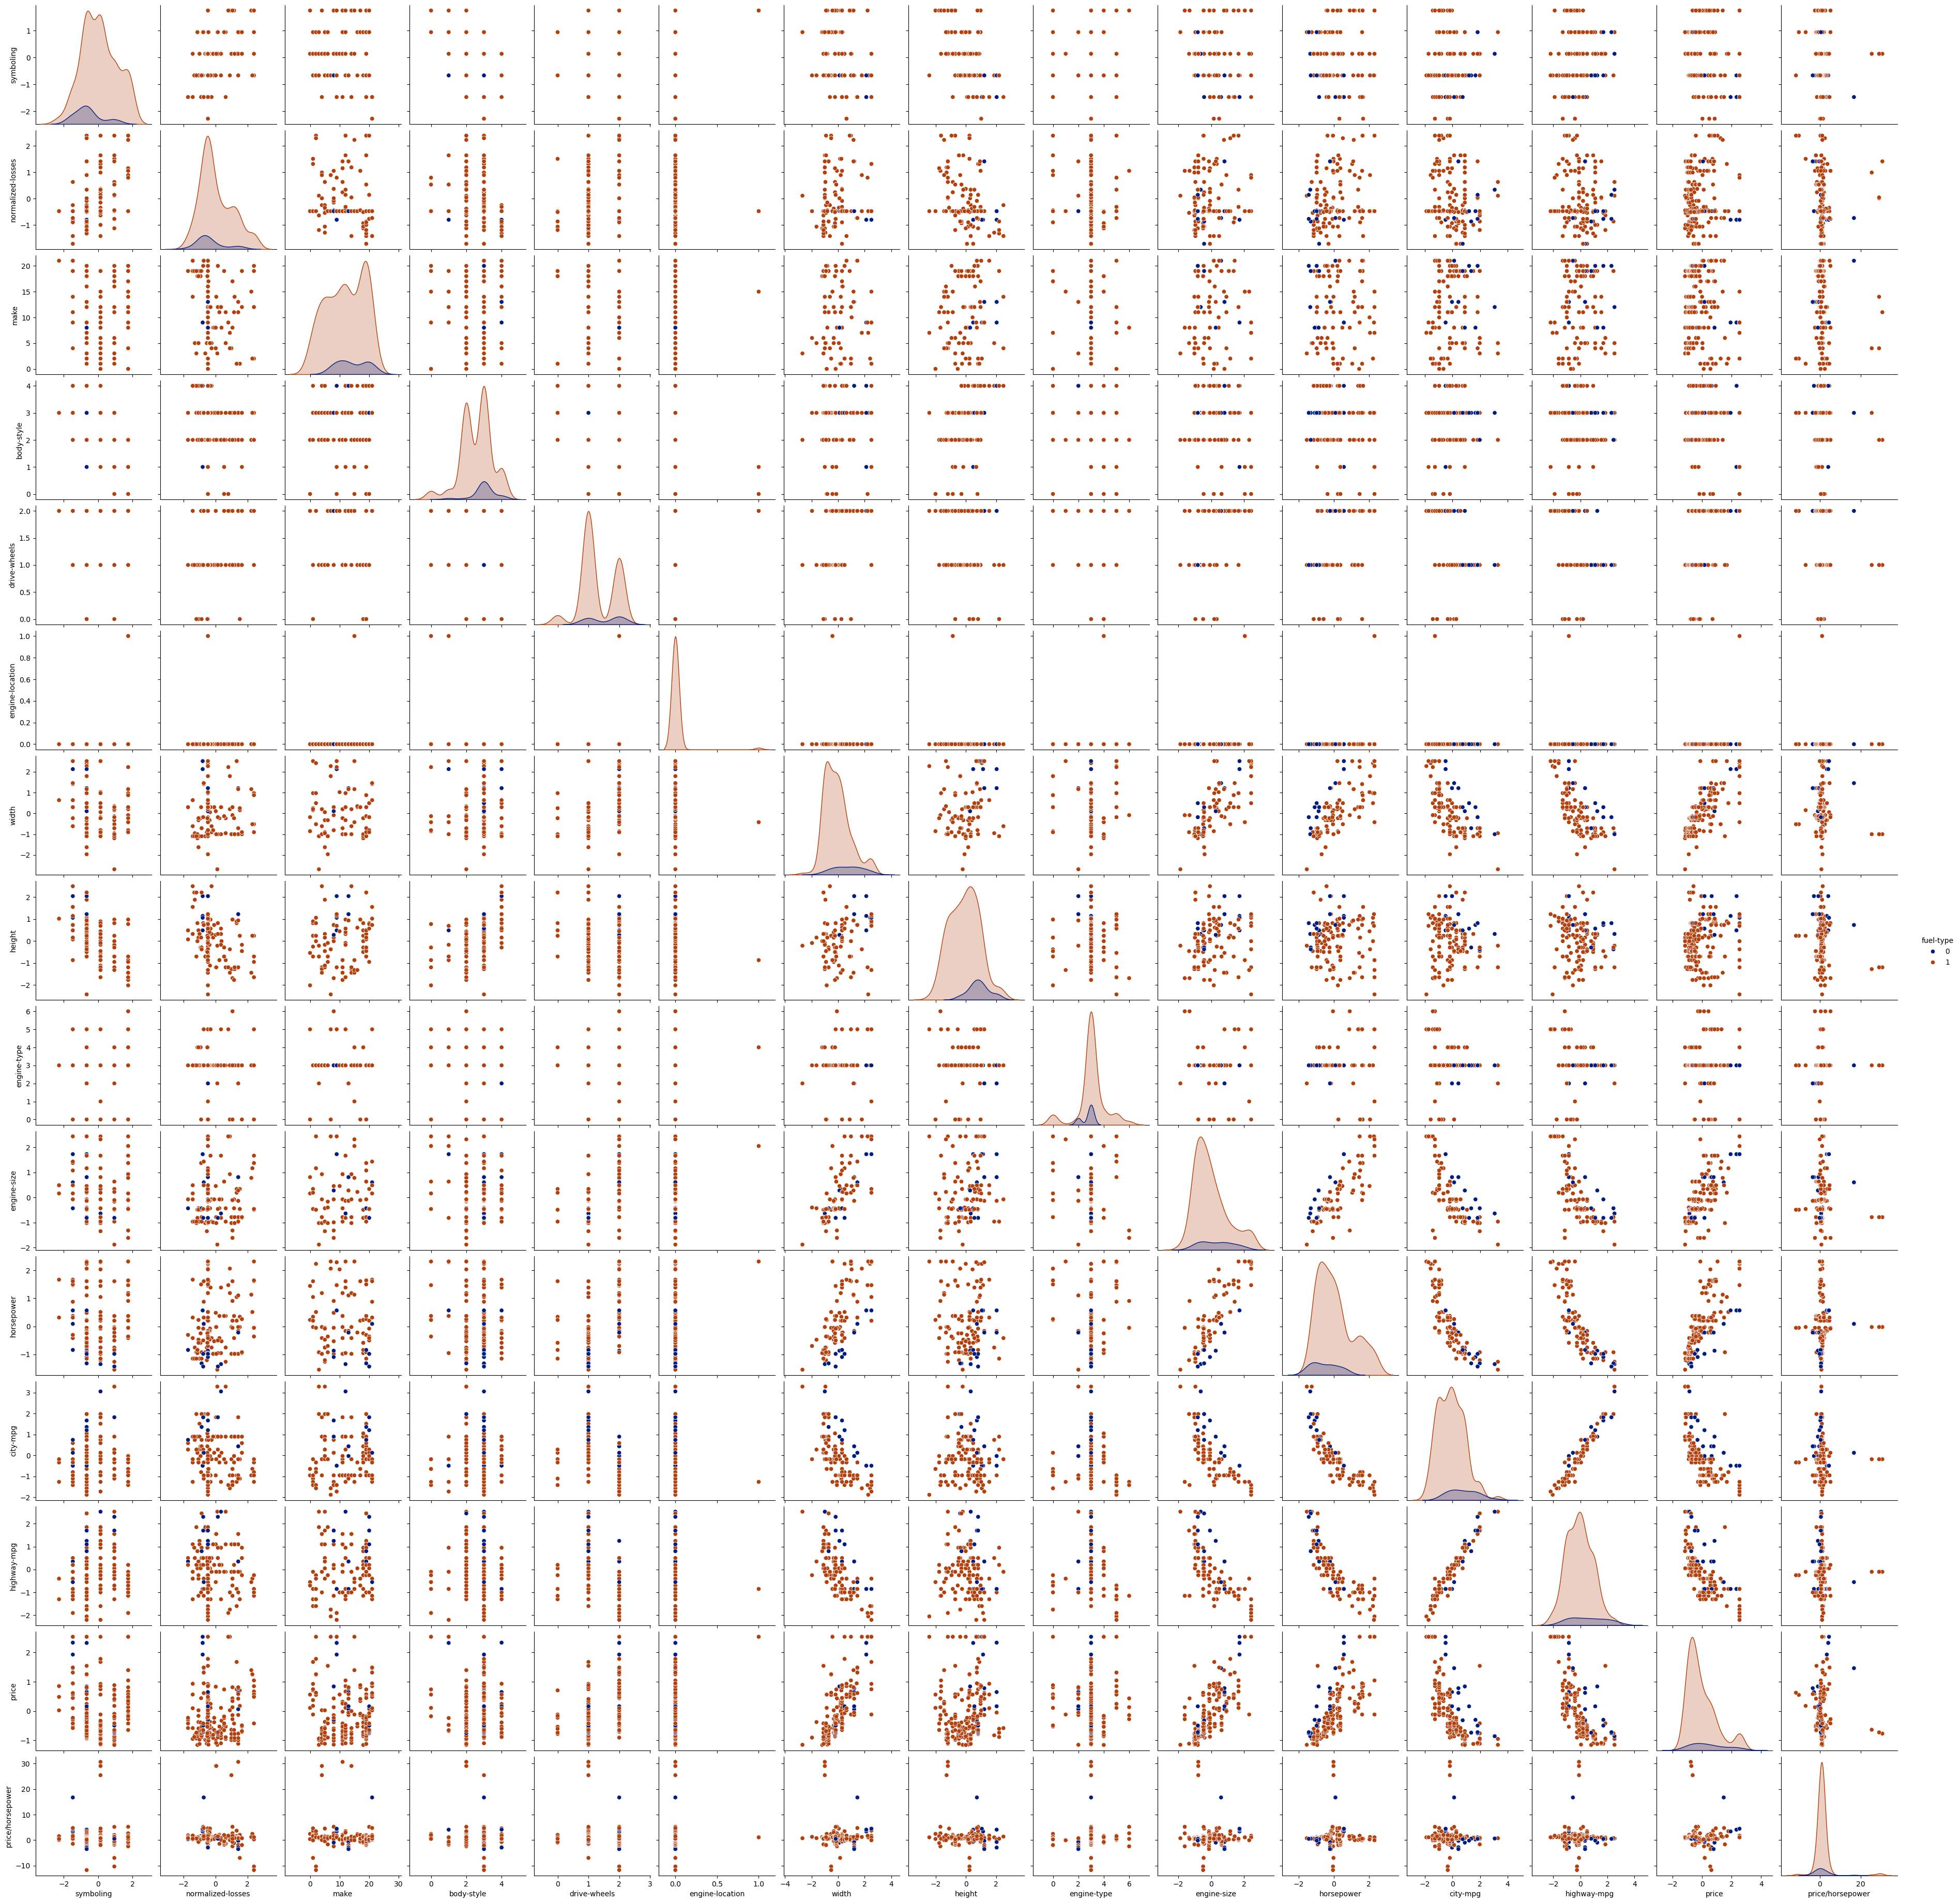

In [348]:
sns.pairplot(adf, hue = 'fuel-type', palette = 'dark')

## train test split

In [349]:
x = adf.drop('price',axis = 1)  # independent variable
y = adf['price'] #target/dependent variable


xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size= 0.2, random_state= 30)


In [350]:
xtrain.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'body-style',
       'drive-wheels', 'engine-location', 'width', 'height', 'engine-type',
       'engine-size', 'horsepower', 'city-mpg', 'highway-mpg',
       'price/horsepower'],
      dtype='object')

In [351]:
xtrain.shape

(164, 15)

In [352]:
ytrain

1      0.560611
112    0.621061
162   -0.533851
87    -0.530678
99    -0.580550
         ...   
140   -0.783967
45     1.542936
173   -0.580701
165   -0.527806
37    -0.739838
Name: price, Length: 164, dtype: float64

## 10: Final Validation and Export

In [275]:
# export to .csv file

In [355]:
adf.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price,price/horsepower
0,1.743470,-0.476253,0,1,0,2,0,-0.858695,-2.020417,0,0.160196,0.228518,-0.649321,-0.552143,0.106474,0.465931
1,1.743470,-0.476253,0,1,0,2,0,-0.858695,-2.020417,0,0.160196,0.228518,-0.649321,-0.552143,0.560611,2.453241
2,0.133509,-0.476253,0,1,2,2,0,-0.184978,-0.543527,5,0.809329,1.440545,-0.958163,-0.702161,0.560611,0.389166
3,0.938490,1.514901,1,1,3,1,0,0.151880,0.235942,3,-0.459430,-0.025162,-0.186058,-0.102086,0.175237,-6.964400
4,0.938490,1.514901,1,1,3,0,0,0.248125,0.235942,3,0.337232,0.341265,-1.112584,-1.302237,0.704181,2.063444


In [356]:
adf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    float64
 1   normalized-losses  205 non-null    float64
 2   make               205 non-null    int64  
 3   fuel-type          205 non-null    int64  
 4   body-style         205 non-null    int64  
 5   drive-wheels       205 non-null    int64  
 6   engine-location    205 non-null    int64  
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    int64  
 10  engine-size        205 non-null    float64
 11  horsepower         205 non-null    float64
 12  city-mpg           205 non-null    float64
 13  highway-mpg        205 non-null    float64
 14  price              205 non-null    float64
 15  price/horsepower   205 non-null    float64
dtypes: float64(10), int64(6)
m

In [359]:
adf.to_csv("Automobile_Data_Analysis_Arya", index = False)